In [8]:
from eggp import EGGP
from reggression import Reggression
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("nikuradse_1.csv")
X = df[['r_k','log_Re']]#.values
y = df.target#.values

In [17]:
def plot_extrapolate(expr, X, y):
    x1 = np.arange(0, 10, 0.001)
    x0 = np.ones(x1.shape)*126
    x = np.vstack([x0,x1]).T

    for ix in expr.index:
        t = eval(expr.loc[ix, 'Parameters'])
        yhat = eval(expr.loc[ix, 'Numpy'])
        if isinstance(yhat,float) or yhat.shape[0] == 1:
            yhat = np.ones(x.shape[0])*yhat
        plt.plot(x1, yhat, label=f"fit.: {expr.loc[ix, 'Fitness']:.2e} / size: {expr.loc[ix, 'Size']}")


    ix = X[:,0] == 126
    plt.plot(X[ix, 1], y[ix], '.', label="true points", markersize=10, alpha=0.5)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$y$")
    plt.legend()
    plt.ylim(0, 2)

In [5]:
reg = EGGP(maxSize=25, gen=200, nPop=300, nonterminals="add,sub,mul,div,powerabs,recip", loss="MSE",
           dumpTo="temp.egraph")
reg.fit(X,y)

,gen,200
,nPop,300
,maxSize,25
,nTournament,3
,pc,0.9
,pm,0.3
,nonterminals,"'add,sub,mul,div,powerabs,recip'"
,loss,'MSE'
,optIter,50
,optRepeat,2
,nParams,-1


In [6]:
egraph = Reggression(dataset="nikuradse_1.csv", loadFrom="temp.egraph", refit=False)

Calculating DL...
Welcome to r🥚ression


<string>:1: RuntimeWarning: divide by zero encountered in divide
<string>:1: RuntimeWarning: overflow encountered in power
<string>:1: RuntimeWarning: divide by zero encountered in reciprocal


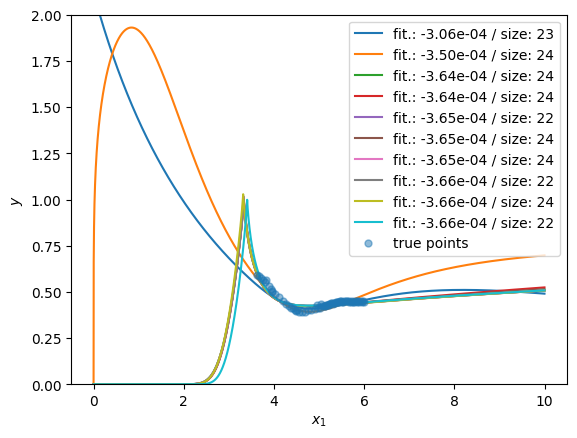

In [22]:
ee = egraph.top(10)
plot_extrapolate(ee, X.values, y.values)
plt.savefig("extrapolate.png")